## YouTube comments - Toxic classification
This notebook takes in a dataset "Youtube Comments Data - Doctor Mike VS 20 Anti-Vaxxers | Surrounded - Jubilee by Manjit Baishya on Kaggle" and attempts to doing NLP and argument mining on the comments.
This is the first notebook in a series of notebooks all using this same dataset. I will not include the complete models but I will provide the outputted datasets or results. 

In [2]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
from collections import Counter
import torch
from transformers import pipeline
from tqdm.notebook import tqdm

nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to C:\Users\Leo
[nltk_data]     H\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [2]:
df = pd.read_csv('comments.csv')

df.describe()

,comment
count,56128
unique,55263
top,😂
freq,37


# Emoji Detection
This section detects any emojis that have been used in a comment and gets the percent of comments with an emoji. 
As of creation I couldnt find any library or dataset that has the classfication of all emojis so it would have been difficult to analyse if they are postitive or negative. The datasets I could find where only limited to around 80-100 emojis. It would also require more context of a comment if it was positive or negative requiring more arugment mining to take full use of them.

In [4]:
# Emoji detection
import emoji

#extract only emojis from the comments
only_emojis = df.apply(lambda x: ''.join(c for c in x if c in emoji.EMOJI_DATA))
print(f"only_emojis: {only_emojis}")

#count lines that contain emojis
lines = df.assign(line=df["comment"].str.split("\n")).explode("line")
line_number = len(lines)
emoji_count = sum(1 for line in lines["line"] if emoji.emoji_list(line))
print(f"Number of lines that contain emojis: {emoji_count}")

lines_with_emoji = emoji_count / line_number * 100

print(f"percent contain emojis: {lines_with_emoji}%")

only_emojis: comment    🚩😭😂🤡😂✡🤌👌🏼❤🥇🤌😭😂💯🔥😂😂😄😆🧜🏿😂😂💯😂🤯🤣😂😂🚩🏆😅💉🤦‍♂️😂😂😭😢🤦‍♀️...
dtype: str
Number of lines that contain emojis: 6284
percent contain emojis: 11.195838084378563%


# Sentiment Analysis
This section takes in the dataset and classifies and counts if a comment in positive, neutral or negative. it then outputs a bar graph on the results. This uses the NLTK package of sentimentIntensityAnalyser. 

Positive comments: 20699
Neutral comments: 16078
Negative comments: 19351


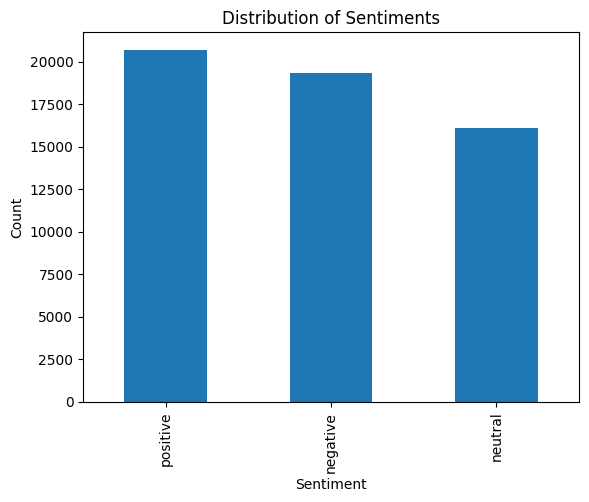

Sentiment Counts:
Counter({'positive': 20699, 'negative': 19351, 'neutral': 16078})


In [5]:
#Sentiment analysis
from nltk.sentiment import SentimentIntensityAnalyzer

sia = nltk.sentiment.SentimentIntensityAnalyzer()


positive_comments = []
neutral_comments = []
negative_comments = []

def get_sentiment(comment):
    score = sia.polarity_scores(comment)
    if score['compound'] >= 0.05:
        return 'positive'
    elif score['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

for comment in df['comment']:
    sentiment = get_sentiment(comment)
    if sentiment == 'positive':
        positive_comments.append(comment)
    elif sentiment == 'negative':
        negative_comments.append(comment)
    else:
        neutral_comments.append(comment)

print(f"Positive comments: {len(positive_comments)}")
print(f"Neutral comments: {len(neutral_comments)}")
print(f"Negative comments: {len(negative_comments)}")


#graph the distribution of sentiments
df['sentiment'] = df['comment'].apply(get_sentiment)
df['sentiment'].value_counts().plot(kind='bar')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.title('Distribution of Sentiments')
plt.show()

#count each comment in each category
labels = [get_sentiment(comment) for comment in df['comment']]
print(f"Sentiment Counts:\n{Counter(labels)}")


# Toxic Comment Classification 
Using the previous sentiment analysis I selected the negative comments and ran them through a pytorch pipeline. This was to classify the comments with tags such as:
- sentiment which was defined earlier so all were negative
- hate_label which were all toxic except an incredibly small sample of obscene
- hate_score which rated how hateful the comment was from 0-1
- emotion which had a mix of various emotions providing a large distrubition of emotions
- emotion_score which rated from 0-1 how emotional a comment was. 

In [6]:
#Toxic comment classification

negative_df = df[df['sentiment'] == 'negative']
print(negative_df.head())

device = 0 if torch.cuda.is_available() else -1

hate_model = pipeline("text-classification",
                      model="unitary/toxic-bert",
                      device=device)

emotion_model = pipeline("text-classification",
                         model="j-hartmann/emotion-english-distilroberta-base",
                         device=device)

texts = negative_df["comment"].astype(str).tolist()
batch_size = 32
max_length = 128

chunks = [texts[i:i+batch_size] for i in range(0, len(texts), batch_size)]


hate_outputs = []
emotional_outputs = []

for chunk in tqdm(chunks, desc="Batches"):
    h_out = hate_model(chunk, truncation=True, max_length=max_length, batch_size=len(chunk))
    e_out = emotion_model(chunk, truncation=True, max_length=max_length, batch_size=len(chunk))

    hate_outputs.extend([o[0] if isinstance(o, list) else o for o in h_out])
    emotional_outputs.extend([o[0] if isinstance(o, list) else o for o in e_out])

res = pd.DataFrame({
    "hate_label": [o["label"] for o in hate_outputs],
    "hate_score": [o["score"] for o in hate_outputs],
    "emotion":    [o["label"] for o in emotional_outputs],
    "emotion_score":[o["score"] for o in emotional_outputs],
})
negative_df = negative_df.reset_index(drop=True).join(res)

negative_df.to_csv("negative_comments_with_labels.csv", index=False)

hate_model.model.save_pretrained("hate_model")
hate_model.tokenizer.save_pretrained("hate_tokenizer")
emotion_model.model.save_pretrained("emotion_model")
emotion_model.tokenizer.save_pretrained("emotion_tokenizer")



                                             comment sentiment
0  A lot of this seems to come down to who contro...  negative
3  After that self appointed redhead scientist, t...  negative
4  "facts can change over time"... The most absur...  negative
7  this proves how dangerous the internet is when...  negative
8                         a bunch of conspiracy nuts  negative


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Batches:   0%|          | 0/605 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('emotion_tokenizer\\tokenizer_config.json',
 'emotion_tokenizer\\tokenizer.json')

# Visualisation
This visualises the new dataset "negative_comments_with_labels.csv" with 2 bar and 2 pie charts to show the distribution of the data.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

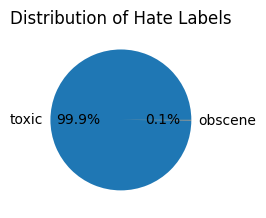

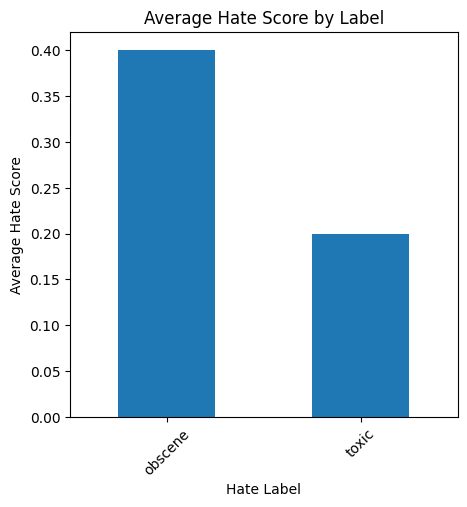

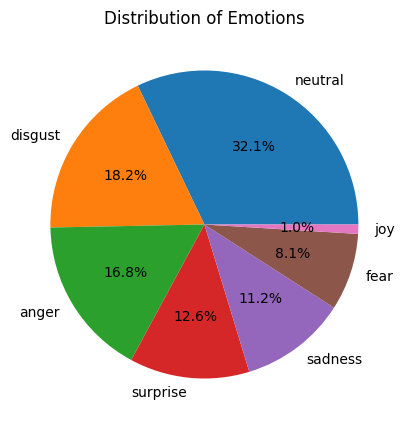

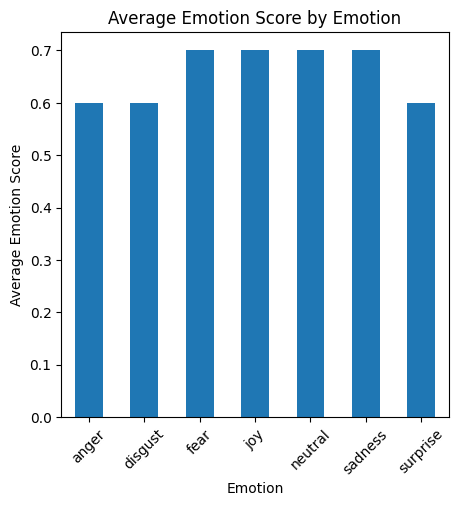

In [9]:
device = 0 if torch.cuda.is_available() else -1

hate_model = pipeline("text-classification",
					  model="./hate_model",
					  tokenizer="./hate_tokenizer",
					  device=device)

negative_df = pd.read_csv("negative_comments_with_labels.csv")

#hate label distribution

hate_label_counts = negative_df['hate_label'].value_counts()

plt.figure(figsize=(5, 5))
plt.subplot(1, 2, 1)
hate_label_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Hate Labels')
plt.ylabel('')

#hate score by label
hate_score_by_label = negative_df.groupby('hate_label')['hate_score'].mean().round(1)

plt.figure(figsize=(5, 5))
hate_score_by_label.plot(kind='bar')
plt.title('Average Hate Score by Label')
plt.xlabel('Hate Label')
plt.ylabel('Average Hate Score')
plt.xticks(rotation=45)
plt.show()


#emotion count distribution

emotion_counts = negative_df['emotion'].value_counts()

plt.figure(figsize=(5, 5))
emotion_counts.plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribution of Emotions')
plt.ylabel('')
plt.show()

#emotion score by emotion
emotion_score_by_emotion = negative_df.groupby('emotion')['emotion_score'].mean().round(1)

plt.figure(figsize=(5, 5))
emotion_score_by_emotion.plot(kind='bar')
plt.title('Average Emotion Score by Emotion')
plt.xlabel('Emotion')
plt.ylabel('Average Emotion Score')
plt.xticks(rotation=45)
plt.show()
